# RT-IDS: Real-Time Network Intrusion Detection for IoT
## PyTorch Deep Neural Network Baseline — CIC-IoT-2023 Dataset

Two classification granularities:

- **2-class** — Benign vs Attack (binary gate)
- **8-class** — Attack families (operational routing)

**Best practices applied:**
1. Raw per-attack CSV ingestion; label derived from folder name
2. Per-class subsampling at ingest to cap majorities
3. Lazy Polars → Zstd-compressed Parquet (fast reloads, low memory)
4. Stratified 70/15/15 train/val/test split
5. `RobustScaler` fit on train only (no test leakage)
6. Class-weighted Cross-Entropy loss (handles extreme imbalance)
7. Early stopping on validation loss
8. Per-mode per-class precision/recall/F1 + normalized confusion matrix
9. Unified comparison table across both tasks

## Methodological Decisions (preempting standard committee critiques)

These four choices shape every result below. They are deliberate, defensible, and called out here so they are not surprises during defense:

1. **39-feature CIC-IoT-2023 release (trimmed to 25 after EDA).** The official UNB CIC website distributes a 39-feature CSV version. Most published papers on this dataset use a 46-feature variant that is not available from the official source; results in this notebook will not be numerically directly comparable to those papers, and that is acknowledged as a scope decision rather than treated as a defect.
2. **Three split strategies, temporal as headline (2-class and 8-class only).** CIC-IoT-2023 flows captured ~50 ms apart in the same attack session look near-identical in the 39-feature representation. A pure random row split lets the model exploit within-session redundancy. We report **temporal** (per-folder, sort source CSVs, train on earliest 70%), **per-CSV** (`GroupShuffleSplit`), and **random** (parity with published numbers). Headline numbers are temporal. The gap between random and temporal quantifies session-level memorization on this dataset and is itself a finding.
3. **Random per-class subsampling with deduplication.** CIC-IoT-2023 contains ~24M exact duplicate rows out of ~46M. We `unique()` per attack folder before sampling, then random-sample to `MAX_ROWS_PER_CLASS` with a fixed seed. This is the dominant approach in the CIC-IoT-2023 literature; sequential `head()` sampling — used in earlier drafts — biases the model toward the opening minutes of each capture session.
4. **"Real-time" scoped to interactive single-flow inference, not line-rate.** The benchmark reports per-batch p50/p95/p99 and end-to-end latency including `scaler.transform`. The thesis claim is that latency is sufficient for an interactive demo (target <100 ms end-to-end). Line-rate gateway deployment (>1M flows/sec) is explicitly out of scope.

**Expected finding worth noting in advance:** the **Web** attack family (SQL injection, XSS, command injection, browser hijacking) is inherently weakly detectable from flow-level statistics alone — these are application-layer attacks and the 39 features describe transport-layer behavior. Lower per-class F1 on Web attacks, and Web↔Benign confusion in the 8-class matrix, is consistent with Neto et al. (2023) and is a property of the feature set, not a model failure.

In [1]:
import os
from pathlib import Path

import numpy as np
import polars as pl
import torch
from torch.utils.data import DataLoader

from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

import joblib
import wandb
import matplotlib.pyplot as plt
import seaborn as sns

from config import (
    DATASET_DIRECTORY, PARQUET_PATH, MODELS_DIR, MAX_ROWS_PER_CLASS,
    X_COLUMNS, Y_COLUMN, N_FEATURES, FLAG_COLUMNS, LOG_COLUMNS,
    MODES_TO_RUN, SPLITS_TO_RUN, BATCH_SIZE, N_EPOCHS, PATIENCE, LR, SEED,
    BATCH_SIZES, N_WARMUP, N_RUNS,
)
from labels import DICT_8CLASSES, DICT_2CLASSES, remap_labels
from preprocessing import SPLIT_FUNCS, fit_preprocess
from models import IDSDataset, IDSModel, train_model, evaluate, device
from benchmark import benchmark_model

In [2]:
print(f'Features: {N_FEATURES} | log1p: {len(LOG_COLUMNS)} | flags: {len(FLAG_COLUMNS)}')
print(f'Per-class cap: {MAX_ROWS_PER_CLASS:,}')
print(f'Modes to run: {MODES_TO_RUN}')
print(f'Splits to run: {SPLITS_TO_RUN}')
print(f'Device: {device}')

Features: 39 | log1p: 17 | flags: 22
Per-class cap: 200,000
Modes to run: ['2', '8']
Splits to run: ['temporal']
Device: cuda


## Label Mappings

Three granularities derived from the 34 attack folders. Keys are **case-sensitive** and must match folder names exactly. An assert at ingest time catches unmapped folders.

---
## Phase 1: Data Ingestion

Build a single deduplicated, sampled, labeled parquet from the per-attack CSV folders. Three steps, each in its own cell:

1. **Discover** — list attack folders and validate them against the 34-class label dictionary.
2. **Process** — per folder: lazily scan CSVs, drop exact duplicates, random-sample to the per-class cap.
3. **Summarize & write** — report dataset-wide duplication totals, then write the parquet.

In [3]:
attack_folders = sorted(
    d for d in os.listdir(DATASET_DIRECTORY)
    if (DATASET_DIRECTORY / d).is_dir()
)
print(f'Found {len(attack_folders)} attack folders')

unmapped = set(attack_folders) - set(DICT_8CLASSES.keys())
if unmapped:
    raise ValueError(f'Unmapped folders (fix DICT_8CLASSES): {unmapped}')

Found 34 attack folders


### Per-folder loop: dedup + random sample

For each attack folder, lazily scan all CSVs, stamp `source_csv` (filename) and materialize, **drop exact duplicates**, then **randomly sample** `MAX_ROWS_PER_CLASS` rows with a fixed seed.

**Why random sample, not `head()`:** each attack folder is a concatenation of sequential capture sessions. `.head(N)` would systematically pull only from the earliest sessions, biasing the model toward whatever happened in the opening minutes. Random sampling with a fixed seed gives a representative cross-session sample while remaining reproducible.

**Why keep `source_csv`:** needed downstream for the per-CSV and temporal splits, which prevent within-session leakage that random row splitting cannot catch.

In [4]:
def run_ingest(attack_folders, dataset_dir, x_columns, y_column, max_rows, seed):
    frames = []
    total_raw = total_unique = total_kept = 0
    class_stats = {}

    for folder in attack_folders:
        folder_path = dataset_dir / folder
        csvs = sorted(folder_path.glob('*.csv'))
        if not csvs:
            continue

        per_file = [
            pl.scan_csv(str(f), infer_schema_length=10000)
                .select(x_columns)
                .with_columns(pl.lit(f.name).alias('source_csv'))
            for f in csvs
        ]
        df_folder = pl.concat(per_file).collect()
        n_raw = df_folder.height

        df_folder = df_folder.unique(subset=x_columns, keep='first')
        n_dedup = df_folder.height

        if max_rows and df_folder.height > max_rows:
            df_folder = df_folder.sample(n=max_rows, seed=seed, shuffle=True)
        n_kept = df_folder.height

        total_raw += n_raw
        total_unique += n_dedup
        total_kept += n_kept

        df_folder = df_folder.with_columns(pl.lit(folder).alias(y_column))
        frames.append(df_folder)
        class_stats[folder] = n_kept

    return frames, total_raw, total_unique, total_kept, class_stats


if PARQUET_PATH.exists():
    print(f'Parquet already exists at {PARQUET_PATH}, skipping ingest.')
    _vc = pl.read_parquet(str(PARQUET_PATH), columns=[Y_COLUMN])[Y_COLUMN].value_counts()
    class_stats = {row[Y_COLUMN]: row['count'] for row in _vc.iter_rows(named=True)}
    total_raw = total_unique = total_kept = None
    frames = None
    del _vc
else:
    frames, total_raw, total_unique, total_kept, class_stats = run_ingest(
        attack_folders, DATASET_DIRECTORY, X_COLUMNS, Y_COLUMN, MAX_ROWS_PER_CLASS, SEED,
    )

Parquet already exists at data\cic_iot_2023.parquet, skipping ingest.


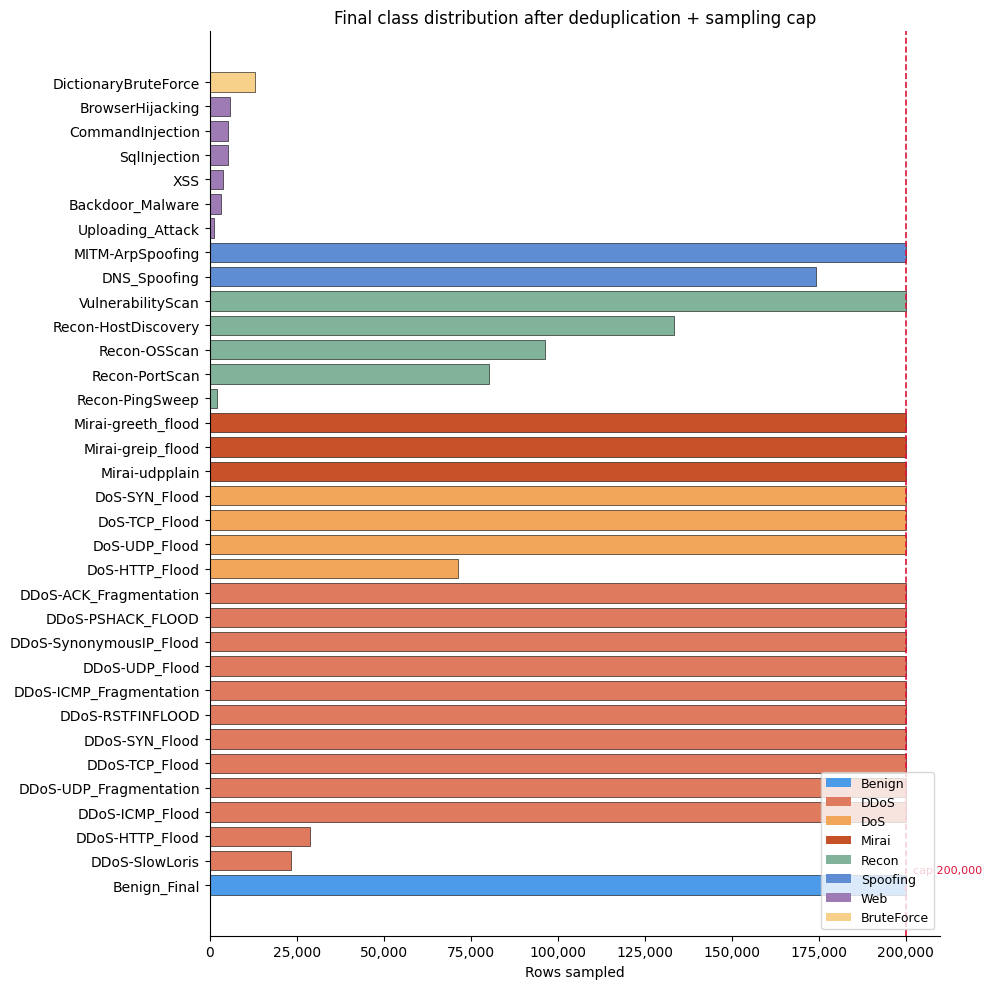

In [5]:
# Plot: final sampled rows per class, grouped by family, sorted by count within each group
FAMILY_COLORS = { 'DDoS': '#e07a5f', 'DoS': '#f2a65a', 'Mirai': '#c7522a', 'Recon': '#81b29a', 'Spoofing': '#5f8dd3', 'Web': '#9e7bb5', 'BruteForce': '#f7d08a', 'Benign': '#4c9be8' }
FAMILY_ORDER = ['Benign', 'DDoS', 'DoS', 'Mirai', 'Recon', 'Spoofing', 'Web', 'BruteForce']

# Sort: primary by family order, secondary by count ascending within each family
folders_sorted = sorted(
    class_stats,
    key=lambda f: (FAMILY_ORDER.index(DICT_8CLASSES[f]), class_stats[f]),
)
counts = [class_stats[f] for f in folders_sorted]
bar_colors = [FAMILY_COLORS[DICT_8CLASSES[f]] for f in folders_sorted]

fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(folders_sorted, counts, color=bar_colors, edgecolor='black', linewidth=0.4)
ax.axvline(MAX_ROWS_PER_CLASS, color='crimson', linestyle='--', linewidth=1.2)
ax.text(MAX_ROWS_PER_CLASS * 1.01, 0.4, f'cap {MAX_ROWS_PER_CLASS:,}',
        color='crimson', va='bottom', fontsize=8)

from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=FAMILY_COLORS[fam], label=fam) for fam in FAMILY_ORDER]
ax.legend(handles=legend_handles, loc='lower right', fontsize=9)

ax.xaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlabel('Rows sampled')
ax.set_title('Final class distribution after deduplication + sampling cap')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

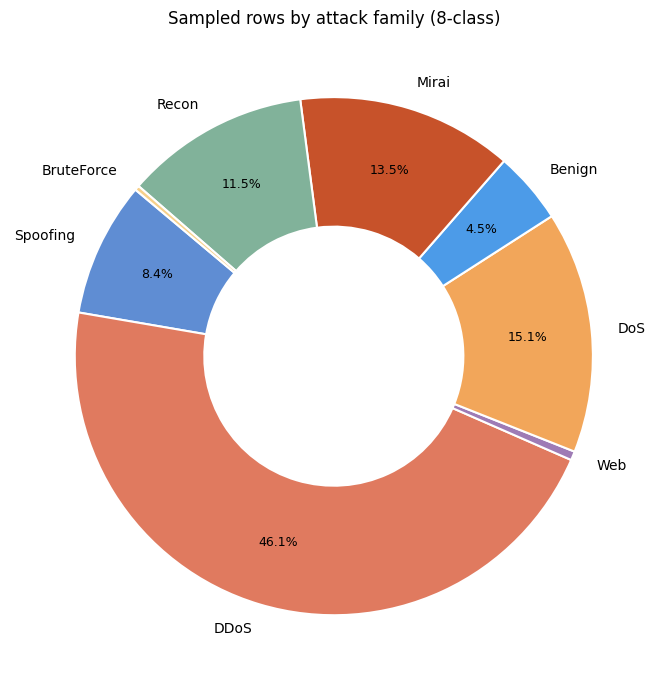

In [6]:
# Donut chart: share of total sampled rows per 8-class family
from collections import defaultdict

family_totals = defaultdict(int)
for folder, n in class_stats.items():
    family_totals[DICT_8CLASSES[folder]] += n

families = list(family_totals.keys())
totals = list(family_totals.values())
colors = [FAMILY_COLORS[f] for f in families]

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    totals, labels=families, colors=colors,
    autopct=lambda p: f'{p:.1f}%' if p > 2 else '',
    pctdistance=0.75, startangle=140,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=1.5),
)
for t in autotexts:
    t.set_fontsize(9)

ax.set_title('Sampled rows by attack family (8-class)')
plt.tight_layout()
plt.show()

### Dataset-wide totals

Sum the per-folder counters into a single duplication summary, then write the combined frame to parquet. Reporting the aggregate raw / unique / duplicate counts confirms the canonical CIC-IoT-2023 finding (~24M duplicates of ~46M raw rows) on this run, rather than leaving it implicit in the per-folder log.

In [7]:
if frames is None:
    print('Skipped ingest — using existing parquet.')
else:
    total_dupes = total_raw - total_unique
    sampling_cut = total_unique - total_kept
    dupe_pct = (total_dupes / total_raw * 100) if total_raw else 0.0
    sample_pct = (sampling_cut / total_unique * 100) if total_unique else 0.0

    labels = ['Raw', '− Duplicates', 'Unique', '− Sampling cap', 'Sampled']
    values = [total_raw, -total_dupes, total_unique, -sampling_cut, total_kept]
    is_total = [True, False, True, False, True]

    cum = 0
    bottoms, heights, colors = [], [], []
    for v, total in zip(values, is_total):
        if total:
            bottoms.append(0)
            heights.append(v)
            colors.append('#4c9be8' if v == total_raw else ('#3aa17e' if v == total_kept else '#7aa6c2'))
            cum = v
        else:
            new = cum + v
            bottoms.append(new)
            heights.append(-v)
            colors.append('#e07a5f')
            cum = new

    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.bar(labels, heights, bottom=bottoms, color=colors, edgecolor='black', linewidth=0.5)

    tops = []
    running = 0
    for v, total in zip(values, is_total):
        running = v if total else running + v
        tops.append(running)
    for i in range(len(tops) - 1):
        ax.plot([i + 0.4, i + 1 - 0.4], [tops[i], tops[i]], 'k--', linewidth=0.7)

    annotations = [
        f'{total_raw:,}',
        f'−{total_dupes:,}\n({dupe_pct:.1f}% of raw)',
        f'{total_unique:,}',
        f'−{sampling_cut:,}\n({sample_pct:.1f}% of unique)',
        f'{total_kept:,}\ncap {MAX_ROWS_PER_CLASS:,}/class',
    ]
    for bar, bottom, height, text in zip(bars, bottoms, heights, annotations):
        ax.text(bar.get_x() + bar.get_width() / 2, bottom + height + total_raw * 0.015,
                text, ha='center', va='bottom', fontsize=9)

    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.set_ylabel('Rows')
    ax.set_ylim(0, total_raw * 1.15)
    ax.set_title(f'CIC-IoT-2023 ingest waterfall — {len(frames)} folders')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

    PARQUET_PATH.parent.mkdir(parents=True, exist_ok=True)
    pl.concat(frames).write_parquet(str(PARQUET_PATH), compression='zstd')
    print(f'Parquet saved to {PARQUET_PATH}')

Skipped ingest — using existing parquet.


### Inspect the saved parquet

Reload from disk and report row counts per 34-class plus the number of distinct source CSVs per folder — the latter feeds the per-CSV and temporal split strategies in Phase 3.

In [8]:
df = pl.read_parquet(str(PARQUET_PATH))
print(f'Rows: {df.shape[0]:,} | Columns: {df.shape[1]}')

print('\nRows per 34-class:')
print(df[Y_COLUMN].value_counts().sort('count', descending=True))

print('\nDistinct source CSVs per attack folder (used by per-CSV / temporal splits):')
print(
    df.group_by(Y_COLUMN)
      .agg(pl.col('source_csv').n_unique().alias('n_csvs'))
      .sort('n_csvs', descending=True)
)

Rows: 4,448,253 | Columns: 41

Rows per 34-class:
shape: (34, 2)
┌────────────────────┬────────┐
│ Label              ┆ count  │
│ ---                ┆ ---    │
│ str                ┆ u32    │
╞════════════════════╪════════╡
│ DoS-UDP_Flood      ┆ 200000 │
│ Mirai-greip_flood  ┆ 200000 │
│ MITM-ArpSpoofing   ┆ 200000 │
│ DDoS-UDP_Flood     ┆ 200000 │
│ Mirai-greeth_flood ┆ 200000 │
│ …                  ┆ …      │
│ SqlInjection       ┆ 5245   │
│ XSS                ┆ 3846   │
│ Backdoor_Malware   ┆ 3215   │
│ Recon-PingSweep    ┆ 2262   │
│ Uploading_Attack   ┆ 1252   │
└────────────────────┴────────┘

Distinct source CSVs per attack folder (used by per-CSV / temporal splits):
shape: (34, 2)
┌──────────────────────┬────────┐
│ Label                ┆ n_csvs │
│ ---                  ┆ ---    │
│ str                  ┆ u32    │
╞══════════════════════╪════════╡
│ Mirai-greeth_flood   ┆ 29     │
│ DDoS-ICMP_Flood      ┆ 27     │
│ Mirai-udpplain       ┆ 25     │
│ Mirai-greip_flood    ┆ 22

---
## Phase 2: Cleaning

1. Drop null-label rows (defensive — labels come from folder names so should be zero)
2. Replace inf/-inf with null (handled by train-fit median imputation later, in `cell:scale`)
3. `log1p(x)` on continuous features — compresses heavy-tailed rate/size distributions. The CIC-IoT-2023 continuous features are all non-negative by construction, so no `abs()` wrapper is needed.

**What's NOT done here:** median imputation. It moved to `cell:scale` so medians are fit on the **train split only** instead of the full pool. This eliminates a (very small) source of test-set leakage.

In [9]:
rows_before = df.shape[0]
df = df.drop_nulls(subset=[Y_COLUMN])
print(f'Dropped {rows_before - df.shape[0]:,} null-label rows ({df.shape[0]:,} remaining)')

Dropped 0 null-label rows (4,448,253 remaining)


In [10]:
df = df.with_columns([
    pl.when(pl.col(c).is_infinite()).then(None).otherwise(pl.col(c)).alias(c)
    for c in X_COLUMNS
])

cols_with_nulls = {c: df[c].null_count() for c in X_COLUMNS if df[c].null_count() > 0}
print(f'{len(cols_with_nulls)} columns carry nulls (from inf→null replacement):')
for col, n in sorted(cols_with_nulls.items(), key=lambda x: -x[1]):
    print(f'  {col:<20} {n:>4} null rows')

3 columns carry nulls (from inf→null replacement):
  Rate                  159 null rows
  Std                   135 null rows
  Variance              135 null rows


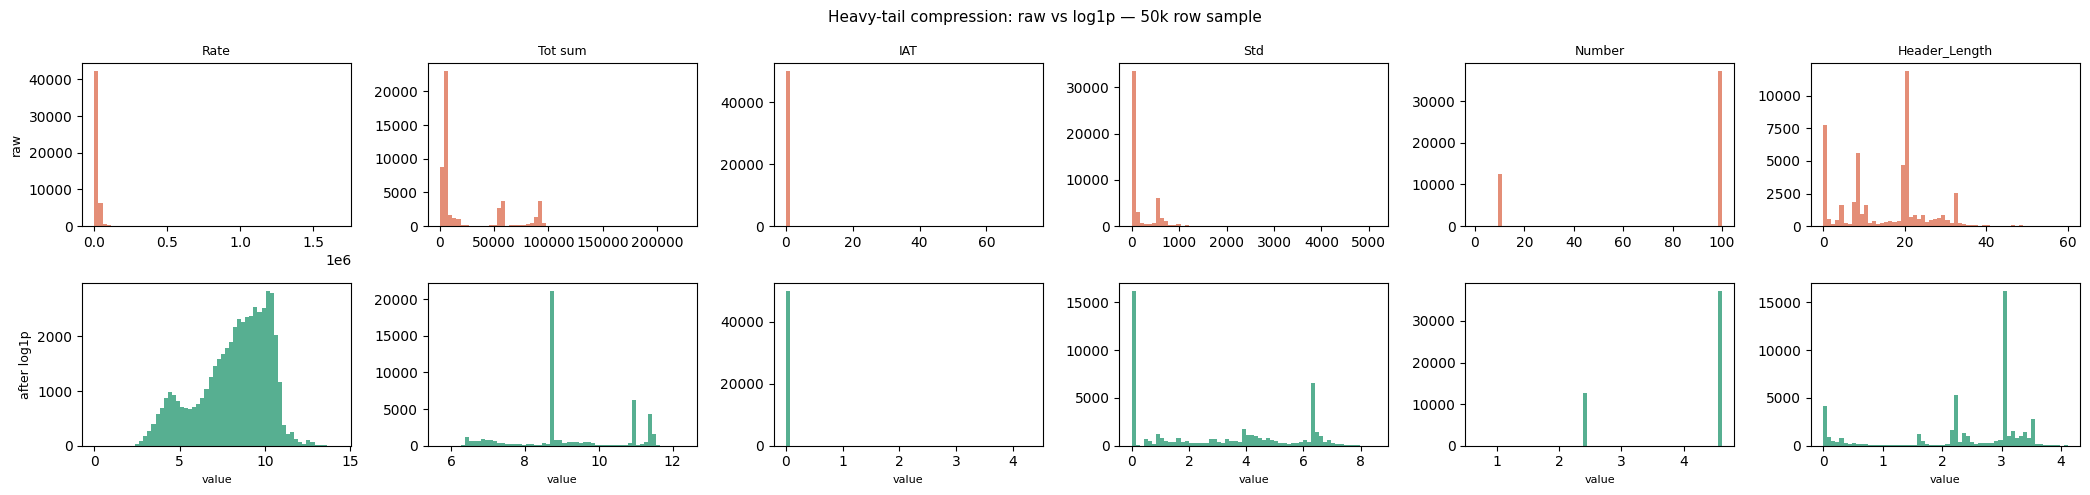

log1p applied to 17 continuous columns
Cleaned dataset: 4,448,253 rows (nulls retained for post-split imputation)


In [11]:
# Sample raw values before transformation for the visual comparison
_n = min(50_000, df.shape[0])
_sample = df.sample(n=_n, seed=SEED).select(LOG_COLUMNS).to_numpy().astype(np.float32)

_plot_cols = ['Rate', 'Tot sum', 'IAT', 'Std', 'Number', 'Header_Length']
fig, axes = plt.subplots(2, len(_plot_cols), figsize=(3.5 * len(_plot_cols), 5))
for j, col in enumerate(_plot_cols):
    idx = LOG_COLUMNS.index(col)
    raw = _sample[:, idx]
    raw = raw[np.isfinite(raw)]
    axes[0, j].hist(raw, bins=60, color='#e07a5f', edgecolor='none', alpha=0.85)
    axes[0, j].set_title(col, fontsize=9)
    axes[1, j].hist(np.log1p(np.clip(raw, 0, None)), bins=60,
                    color='#3aa17e', edgecolor='none', alpha=0.85)
    axes[1, j].set_xlabel('value', fontsize=8)
axes[0, 0].set_ylabel('raw', fontsize=9)
axes[1, 0].set_ylabel('after log1p', fontsize=9)
fig.suptitle('Heavy-tail compression: raw vs log1p — 50k row sample', fontsize=11)
plt.tight_layout()
plt.show()
del _sample

df = df.with_columns([pl.col(c).log1p().alias(c) for c in LOG_COLUMNS])
print(f'log1p applied to {len(LOG_COLUMNS)} continuous columns')
print(f'Cleaned dataset: {df.shape[0]:,} rows (nulls retained for post-split imputation)')

### Feature Analysis

Two diagnostic checks before splitting, using the cleaned post-log1p dataset.

---

#### Variance check (binary flags)

For a binary random variable $X \in \{0, 1\}$ with $p = P(X=1)$:

$$\text{Var}(X) = p(1-p)$$

This is maximised at $p = 0.5$ (Var = 0.25) and approaches 0 when $p \to 0$ or $p \to 1$.
A threshold of $\text{Var} < 0.01$ implies the flag is set in fewer than ~1% of flows across the entire dataset — it is near-constant and contributes no discriminative signal to any classifier.

---

#### Pearson correlation (continuous features)

$$r_{XY} = \frac{\sum_i (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_i (x_i - \bar{x})^2}\;\sqrt{\sum_i (y_i - \bar{y})^2}} \in [-1, 1]$$

$|r| \approx 1$ means the two features carry near-identical information: one is a linear function of the other.
Keeping both wastes a model parameter without adding information.

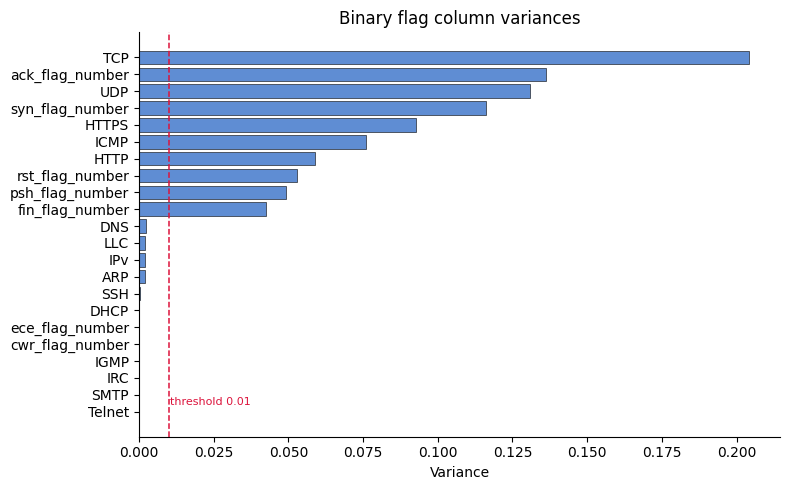

Near-constant flags (var < 0.01): ['ece_flag_number', 'cwr_flag_number', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'DHCP', 'ARP', 'IGMP', 'IPv', 'LLC']


In [13]:
_flag_vals = df.select(FLAG_COLUMNS).to_numpy().astype(np.float32)
_flag_var = _flag_vals.var(axis=0)

sorted_flags = sorted(zip(FLAG_COLUMNS, _flag_var), key=lambda x: x[1])
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh([f for f, _ in sorted_flags], [v for _, v in sorted_flags],
        color='#5f8dd3', edgecolor='black', linewidth=0.4)
ax.axvline(0.01, color='crimson', linestyle='--', linewidth=1.1)
ax.text(0.0105, 0.3, 'threshold 0.01', color='crimson', va='bottom', fontsize=8)
ax.set_xlabel('Variance')
ax.set_title('Binary flag column variances')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

low_var = [(c, v) for c, v in zip(FLAG_COLUMNS, _flag_var) if v < 0.01]
if low_var:
    print(f'Near-constant flags (var < 0.01): {[c for c, _ in low_var]}')
else:
    print('All flag columns have variance >= 0.01 — none are near-constant.')
del _flag_vals, _flag_var

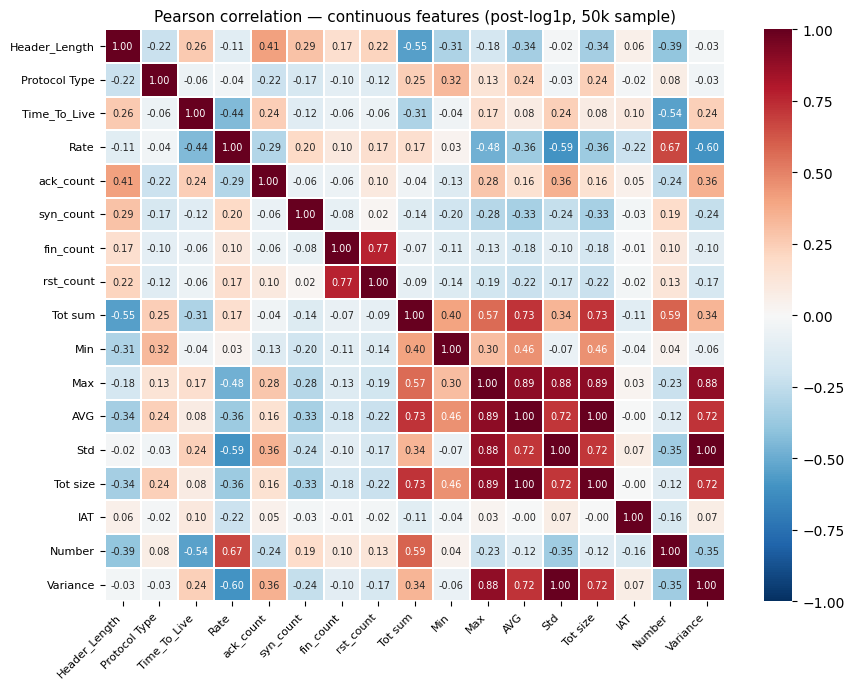

Highly correlated pairs (|r| >= 0.95):
  AVG <-> Tot size: r = 1.000
  Std <-> Variance: r = 0.999


In [14]:
_n_corr = min(50_000, df.shape[0])
_cont = df.sample(n=_n_corr, seed=SEED).select(LOG_COLUMNS).to_numpy().astype(np.float64)
_cont = np.where(np.isnan(_cont), np.nanmean(_cont, axis=0), _cont)
corr = np.corrcoef(_cont.T)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr, xticklabels=LOG_COLUMNS, yticklabels=LOG_COLUMNS,
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    linewidths=0.3, ax=ax,
)
ax.set_title('Pearson correlation — continuous features (post-log1p, 50k sample)', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

threshold = 0.95
pairs = [
    (LOG_COLUMNS[i], LOG_COLUMNS[j], corr[i, j])
    for i in range(len(LOG_COLUMNS))
    for j in range(i + 1, len(LOG_COLUMNS))
    if abs(corr[i, j]) >= threshold
]
if pairs:
    print(f'Highly correlated pairs (|r| >= {threshold}):')
    for a, b, r in sorted(pairs, key=lambda x: -abs(x[2])):
        print(f'  {a} <-> {b}: r = {r:.3f}')
else:
    print(f'No feature pairs with |r| >= {threshold}')
del _cont

#### Correlation findings

Two pairs exceed $|r| \geq 0.95$ and warrant an explicit note.

---

**`Std` vs `Variance` ($r = 0.999$) — mathematical redundancy**

By definition, $\text{Variance} = \text{Std}^2$. After the log1p transform applied in Phase 2:

$$\text{log1p}(\text{Variance}) = \ln(1 + \text{Std}^2)$$

For large values ($\text{Std} \gg 1$), $\ln(1 + x^2) \approx 2\ln(x)$ while $\ln(1+x) \approx \ln(x)$, so:

$$\text{log1p}(\text{Variance}) \approx 2 \cdot \text{log1p}(\text{Std})$$

This is an exact linear rescaling, which is why Pearson $r \approx 1$ post-log1p. `Variance` is dropped; `Std` is retained.

---

**`AVG` vs `Tot size` ($r = 1.000$) — CICFlowMeter artefact**

CICFlowMeter computes:

$$\text{AVG} = \frac{\text{Tot size}}{\text{Number}}$$

For scripted attack traffic the packet count `Number` is near-constant across flows within a session, so `AVG` $\propto$ `Tot size` with an approximately constant ratio. `Tot size` is dropped; `AVG` is retained.

---

**Implication for dimensionality reduction**

These near-duplicate pairs are why PCA would be misleading here: it would construct components mixing them, obscuring their physical meaning. The feature set is instead pruned directly based on redundancy and importance, keeping remaining features interpretable.

### Feature Selection

Based on the two EDA checks above:
- **Variance check** — drop near-constant binary flags (Var < 0.01)
- **Correlation matrix** — drop exact mathematical duplicates (|r| >= 0.95)

The cell below applies both decisions explicitly, reassigning `X_COLUMNS`, `FLAG_COLUMNS`, `LOG_COLUMNS`, and `N_FEATURES` for all downstream phases.

In [ ]:
# ── Dropped: mathematical redundancy (correlation |r| >= 0.95) ───────────
DROPPED_REDUNDANT = [
    'Tot size',   # r = 1.000 with AVG (AVG = Tot size / Number; constant packet count)
    'Variance',   # r = 0.999 with Std (Variance = Std^2 -> linear after log1p)
]

# ── Dropped: near-constant binary flags (Var < 0.01) ─────────────────────
DROPPED_LOW_VAR = [
    'ece_flag_number',  # 0.0000 - TCP ECN flag, almost never set
    'cwr_flag_number',  # 0.0000 - TCP congestion flag, same
    'IGMP',             # 0.0000 - multicast protocol absent from attack patterns
    'IRC',              # 0.0000 - legacy protocol not present in capture sessions
    'Telnet',           # 0.0000 - not discriminative at flow-stat level
    'SMTP',             # 0.0000 - email protocol absent from IoT attack flows
    'DHCP',             # 0.0003 - near-zero
    'SSH',              # 0.0006 - near-zero
    'ICMP',             # 0.0006 - near-zero
    'ARP',              # 0.0009 - near-zero
    'LLC',              # 0.0009 - layer-2 framing, not informative at IP-flow level
    'IPv',              # 0.0013 - near-constant across all flows
]

DROPPED_FEATURES = set(DROPPED_REDUNDANT + DROPPED_LOW_VAR)

X_COLUMNS  = [c for c in X_COLUMNS  if c not in DROPPED_FEATURES]
FLAG_COLUMNS = [c for c in FLAG_COLUMNS if c not in DROPPED_FEATURES]
LOG_COLUMNS  = [c for c in X_COLUMNS  if c not in FLAG_COLUMNS]
N_FEATURES   = len(X_COLUMNS)

print(f'Dropped {len(DROPPED_FEATURES)} features: {len(DROPPED_REDUNDANT)} redundant + {len(DROPPED_LOW_VAR)} near-constant')
print(f'Remaining: {N_FEATURES} features ({len(FLAG_COLUMNS)} flags, {len(LOG_COLUMNS)} continuous)')
print(f'X_COLUMNS: {X_COLUMNS}')

---
## Phase 3: Train/Val/Test Splits — Three Strategies

`train_test_split` on rows assumes IID samples. CIC-IoT-2023 violates this: flows captured 50 ms apart in the same attack session look near-identical in the 39-feature representation. A pure row split puts those near-twins on both sides of the boundary, inflating accuracy. We report **three split strategies** so the gap quantifies how much of the published headline number was within-session memorization:

1. **Temporal** *(headline)* — per attack folder, sort source CSVs by filename and assign the earliest 70% to train, next 15% to val, latest 15% to test. Mirrors deployment: train on past, test on future. Catches concept drift within capture sessions.
2. **Per-CSV** — `GroupShuffleSplit` with source CSV as the group, ensures no CSV is split across train/val/test. Removes within-session leakage but ignores temporal order.
3. **Random row** — original stratified row split. Reported only for parity with published CIC-IoT-2023 numbers (which all use this).

Same per-mode label mapping (2/8) and same `LabelEncoder` logic applied to each split.

**Stratification:** the random split stratifies on the 34-class label (rare-class protection). The per-CSV and temporal splits stratify implicitly via per-folder splitting — every attack class appears in every split as long as its folder has ≥3 CSVs (folders with fewer use a row-level temporal fallback inside the folder).

In [15]:
X_all = df.select(X_COLUMNS).to_numpy().astype(np.float32)
y_all_34 = df[Y_COLUMN].to_numpy()
source_csv_all = df['source_csv'].to_numpy()
del df

SPLIT_INDICES = {}
for name in SPLITS_TO_RUN:
    tr, va, te = SPLIT_FUNCS[name](y_all_34, source_csv_all, SEED)
    SPLIT_INDICES[name] = (tr, va, te)
    print(f'{name:>10}: train {len(tr):>10,} | val {len(va):>10,} | test {len(te):>10,}')

# Sanity: every split should cover every 34-class
for name, (tr, va, te) in SPLIT_INDICES.items():
    missing = set(np.unique(y_all_34)) - set(np.unique(y_all_34[tr]))
    if missing:
        print(f'  WARNING ({name}): {len(missing)} classes absent from train: {missing}')

  temporal: train  3,137,865 | val    667,827 | test    642,561


---
## Phase 4: Train-Fit Imputation + Robust Scaling

For each split: compute column medians on **train only**, fill val/test nulls with those medians, then `RobustScaler` (also fit on train only). Both fits stay strictly on the training partition for that split — no information leaks from val/test into the preprocessing.

In [16]:
_split = SPLITS_TO_RUN[0]
_tr, _va, _te = SPLIT_INDICES[_split]
_X_tr, _X_va, _X_te, _scaler, _medians = fit_preprocess(X_all, _tr, _va, _te)

_total = len(_tr) + len(_va) + len(_te)
print(f'Split "{_split}": train {len(_tr):,} ({len(_tr)/_total:.0%}) | val {len(_va):,} ({len(_va)/_total:.0%}) | test {len(_te):,} ({len(_te)/_total:.0%})')

null_cols = [X_COLUMNS[i] for i in range(len(X_COLUMNS)) if np.isnan(X_all[_tr, i]).any()]
print(f'Median-imputed columns: {null_cols}')
print(f'Scaler center range:  [{_scaler.center_.min():.3f}, {_scaler.center_.max():.3f}]')
print(f'Scaler scale (IQR):   [{_scaler.scale_.min():.3f}, {_scaler.scale_.max():.3f}]')

del _X_tr, _X_va, _X_te, _scaler, _medians

Split "temporal": train 3,137,865 (71%) | val 667,827 (15%) | test 642,561 (14%)
Median-imputed columns: ['Rate', 'Std', 'Variance']
Scaler center range:  [0.000, 8.704]
Scaler scale (IQR):   [0.001, 10.529]


---
## Phase 5: Dataset, Model, Training Utilities

- `IDSDataset` — tensor wrapper for DataLoader
- `IDSModel` — 2-layer MLP with BatchNorm + Dropout
- `train_model` — class-weighted CE, early stopping on val loss
- `evaluate` — metrics + confusion matrix on test

BatchNorm stabilizes training under large class-weight swings (34-class weights can span 50×+ the minimum).

In [17]:
_model_demo = IDSModel(N_FEATURES, n_classes=34)
print(_model_demo)
n_params = sum(p.numel() for p in _model_demo.parameters())
print(f'Total trainable parameters: {n_params:,}')
del _model_demo

IDSModel(
  (net): Sequential(
    (0): Linear(in_features=39, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=34, bias=True)
  )
)
Total trainable parameters: 15,970


---
## Phase 5b: Hyperparameter Optimisation (Optuna)

Before committing to a fixed architecture, we search the MLP hyperparameter space using **Optuna** with the TPE (Tree-structured Parzen Estimator) sampler and MedianPruner.

**Search space:**

| Parameter | Range | Scale |
|---|---|---|
| `n_layers` | 2 – 4 | categorical |
| `hidden_size` per layer | 64 – 512 | int (step 32) |
| `dropout` | 0.1 – 0.5 | float |
| `lr` | 1e-4 – 1e-2 | log |
| `optimizer` | Adam, AdamW | categorical |
| `batch_size` | 1024, 2048, 4096, 8192 | categorical |
| `activation` | ReLU, ELU, LeakyReLU | categorical |

Each trial trains on the temporal split's train partition and is evaluated on validation loss. The **MedianPruner** kills unpromising trials after 5 epochs if their val loss exceeds the median of completed trials, making the search ~3× faster.

The best hyperparameters are printed and used for the final training run in Phase 6.

In [18]:
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Use temporal split + 2-class for the search (fastest signal)
_tune_split  = 'temporal'
_tune_mode   = '2'
_n_trials    = 15
_tune_epochs = 10   # cap per trial; early stopping still applies

_tr_full, _va, _te = SPLIT_INDICES[_tune_split]
_rng = np.random.default_rng(SEED)
_tr = _rng.choice(_tr_full, size=min(100_000, len(_tr_full)), replace=False)
_X_tr, _X_va, _, _scaler_tune, _ = fit_preprocess(X_all, _tr, _va, _te)
_X_tr_t = torch.tensor(_X_tr, dtype=torch.float32)
_X_va_t = torch.tensor(_X_va, dtype=torch.float32)
del _X_tr, _X_va

_y_tr_s  = remap_labels(y_all_34[_tr], _tune_mode)
_y_va_s  = remap_labels(y_all_34[_va], _tune_mode)
_le_tune = LabelEncoder()
_known   = sorted(set(DICT_2CLASSES.values()))
_le_tune.fit(_known)
_y_tr_enc = _le_tune.transform(_y_tr_s)
_y_va_enc = _le_tune.transform(_y_va_s)
_n_cls    = len(_le_tune.classes_)

_present  = np.unique(_y_tr_enc)
_w        = compute_class_weight('balanced', classes=_present, y=_y_tr_enc)
_wfull    = np.ones(_n_cls, dtype=np.float32)
_wfull[_present] = _w
_weights_t = torch.tensor(_wfull, dtype=torch.float32)


def _objective(trial):
    # ── Architecture ─────────────────────────────────────────────────────
    n_layers   = trial.suggest_int('n_layers', 2, 4)
    hidden     = [
        trial.suggest_int(f'hidden_{i}', 64, 512, step=32)
        for i in range(n_layers)
    ]
    dropout    = trial.suggest_float('dropout', 0.1, 0.5)
    activation = trial.suggest_categorical('activation', ['relu', 'elu', 'leakyrelu'])

    # ── Optimiser & training ──────────────────────────────────────────────
    lr         = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    opt_name   = trial.suggest_categorical('optimizer', ['adam', 'adamw'])
    batch_size = trial.suggest_categorical('batch_size', [2048, 4096, 8192])

    gen = torch.Generator().manual_seed(SEED)
    train_loader = DataLoader(
        IDSDataset(_X_tr_t, torch.tensor(_y_tr_enc, dtype=torch.long)),
        batch_size=batch_size, shuffle=True, generator=gen,
        num_workers=0, pin_memory=(device.type == 'cuda'),
    )
    val_loader = DataLoader(
        IDSDataset(_X_va_t, torch.tensor(_y_va_enc, dtype=torch.long)),
        batch_size=batch_size, num_workers=0, pin_memory=(device.type == 'cuda'),
    )

    model = IDSModel(N_FEATURES, _n_cls,
                     hidden_sizes=hidden, dropout=dropout, activation=activation).to(device)

    _, history = train_model(
        model, train_loader, val_loader, _weights_t,
        _tune_epochs, PATIENCE, lr, device,
        optimizer_name=opt_name, trial=trial,
    )
    return min(history['val_loss'])


import tempfile, os
_db_path = os.path.join(tempfile.gettempdir(), 'optuna_ids.db')
study = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=SEED),
    pruner=MedianPruner(n_startup_trials=3, n_warmup_steps=3),
    storage=f'sqlite:///{_db_path}',
    study_name='ids-hparam-search',
    load_if_exists=True,
)
study.optimize(_objective, n_trials=_n_trials, n_jobs=2, show_progress_bar=True)

best = study.best_params
print(f'\nBest val loss: {study.best_value:.4f}')
print(f'Best params:')
for k, v in best.items():
    print(f'  {k}: {v}')

# Build best hidden_sizes list from individual keys
BEST_HIDDEN  = [best[f'hidden_{i}'] for i in range(best['n_layers'])]
BEST_DROPOUT = best['dropout']
BEST_LR      = best['lr']
BEST_OPT     = best['optimizer']
BEST_BATCH   = best['batch_size']
BEST_ACT     = best['activation']

print(f'\nArchitecture: {N_FEATURES} -> {" -> ".join(str(h) for h in BEST_HIDDEN)} -> n_classes')
print(f'Dropout: {BEST_DROPOUT:.3f} | LR: {BEST_LR:.2e} | Optimizer: {BEST_OPT} | Activation: {BEST_ACT}')
print(f'Batch size: {BEST_BATCH}')

# Log best trial to wandb
_run_hp = wandb.init(project='cic-iot2023-ids', name='optuna-best-trial', job_type='hparam-search')
_run_hp.log({'best_val_loss': study.best_value, **best})
_run_hp.log({
    'optuna_trials': wandb.Table(
        columns=['number', 'val_loss', 'state'] + list(best.keys()),
        data=[
            [t.number, t.value if t.value else None, str(t.state)] +
            [t.params.get(k) for k in best.keys()]
            for t in study.trials
        ]
    )
})
wandb.finish()

del _X_tr_t, _X_va_t, _scaler_tune

g:\uni\cic-iot2023-detection-system\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  0%|          | 0/15 [00:00<?, ?it/s]g:\uni\cic-iot2023-detection-system\models.py:82: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
g:\uni\cic-iot2023-detection-system\models.py:95: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
g:\uni\cic-iot2023-detection-system\models.py:108: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


  Epoch 01 — train: 0.4632 — val: 0.2362 — lr: 9.61e-03
  Epoch 01 — train: 0.2994 — val: 0.3212 — lr: 3.71e-03
  Epoch 02 — train: 0.2506 — val: 0.2810 — lr: 9.61e-03
  Epoch 02 — train: 0.2221 — val: 0.2609 — lr: 3.71e-03
  Epoch 03 — train: 0.2327 — val: 0.3058 — lr: 9.61e-03
  Epoch 04 — train: 0.2258 — val: 0.2821 — lr: 4.80e-03
  Epoch 03 — train: 0.2161 — val: 0.2771 — lr: 3.71e-03
  Epoch 05 — train: 0.2225 — val: 0.2874 — lr: 4.80e-03
  Epoch 04 — train: 0.2103 — val: 0.2863 — lr: 3.71e-03


Best trial: 1. Best value: 0.236202:   7%|▋         | 1/15 [01:43<24:02, 103.02s/it]

  Epoch 06 — train: 0.2183 — val: 0.2929 — lr: 4.80e-03
  Early stop @ epoch 6
  Epoch 05 — train: 0.2032 — val: 0.2666 — lr: 1.86e-03
  Epoch 01 — train: 0.5388 — val: 0.5452 — lr: 1.02e-04
  Epoch 06 — train: 0.1974 — val: 0.2811 — lr: 1.86e-03
  Epoch 02 — train: 0.4092 — val: 0.5467 — lr: 1.02e-04
  Epoch 03 — train: 0.3531 — val: 0.5091 — lr: 1.02e-04
  Epoch 07 — train: 0.1917 — val: 0.2538 — lr: 1.86e-03
  Epoch 04 — train: 0.3200 — val: 0.4705 — lr: 1.02e-04
  Epoch 08 — train: 0.1916 — val: 0.2684 — lr: 1.86e-03
  Epoch 05 — train: 0.2985 — val: 0.4330 — lr: 1.02e-04
  Epoch 09 — train: 0.1877 — val: 0.2765 — lr: 1.86e-03
  Epoch 06 — train: 0.2838 — val: 0.4237 — lr: 1.02e-04
  Epoch 10 — train: 0.1845 — val: 0.2689 — lr: 9.28e-04


Best trial: 1. Best value: 0.236202:  13%|█▎        | 2/15 [03:46<24:55, 115.02s/it]

...

Best trial: 14. Best value: 0.205115: 100%|██████████| 15/15 [15:48<00:00, 63.23s/it]
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Rares Marta\_netrc.


  Epoch 10 — train: 0.1773 — val: 0.2636 — lr: 4.10e-03

Best val loss: 0.2051
Best params:
  n_layers: 3
  hidden_0: 192
  hidden_1: 384
  hidden_2: 192
  dropout: 0.12145843432900201
  activation: relu
  lr: 0.008205222564906136
  optimizer: adam
  batch_size: 2048

Architecture: 39 -> 192 -> 384 -> 192 -> n_classes
Dropout: 0.121 | LR: 8.21e-03 | Optimizer: adam | Activation: relu
Batch size: 2048


wandb: Currently logged in as: rares-marta14 (rares-marta14-babes-bolyai-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


batch_size,▁
best_val_loss,▁
dropout,▁
hidden_0,▁
hidden_1,▁
hidden_2,▁
lr,▁
n_layers,▁
activation,relu
batch_size,2048
best_val_loss,0.20512


---
## Phase 6: Train Across Splits × Modes

Outer loop: each split strategy (temporal / per-CSV / random). Inner loop: each granularity (2/8).

For each `(split, mode)`:
- Slice `X_all`/`y_all_34` with the split's train/val/test indices
- Train-fit median imputation + RobustScaler
- Remap labels (2/8) and fit `LabelEncoder`
- Compute class weights from **train-only** label distribution
- Train MLP with class-weighted CE, ReduceLROnPlateau, early stopping
- Evaluate on test once

Results stored as `results[(split, mode)] = metrics`.

In [19]:
models = {}
encoders = {}
scalers = {}
results = {}
histories = {}

for split_name in SPLITS_TO_RUN:
    print(f'\n{"=" * 60}\nSPLIT: {split_name}\n{"=" * 60}')
    tr_idx, va_idx, te_idx = SPLIT_INDICES[split_name]

    X_train, X_val, X_test, scaler, _ = fit_preprocess(X_all, tr_idx, va_idx, te_idx)
    scalers[split_name] = scaler

    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    X_test_t = torch.tensor(X_test, dtype=torch.float32)
    del X_train, X_val, X_test

    y_train_34 = y_all_34[tr_idx]
    y_val_34 = y_all_34[va_idx]
    y_test_34 = y_all_34[te_idx]

    for mode in MODES_TO_RUN:
        key = (split_name, mode)
        print(f'\n--- {split_name} / {mode}-class ---')
        y_train_s = remap_labels(y_train_34, mode)
        y_val_s = remap_labels(y_val_34, mode)
        y_test_s = remap_labels(y_test_34, mode)

        le = LabelEncoder()
        all_known = sorted(set(DICT_8CLASSES.values()) if mode == '8'
                           else set(DICT_2CLASSES.values()) if mode == '2'
                           else set(DICT_8CLASSES.keys()))
        le.fit(all_known)
        y_train_enc = le.transform(y_train_s)
        y_val_enc = le.transform(y_val_s)
        y_test_enc = le.transform(y_test_s)
        n_classes = len(le.classes_)

        present_classes = np.unique(y_train_enc)
        weights = compute_class_weight('balanced', classes=present_classes, y=y_train_enc)
        full_weights = np.ones(n_classes, dtype=np.float32)
        full_weights[present_classes] = weights
        weights_t = torch.tensor(full_weights, dtype=torch.float32)
        print(f'  Classes ({n_classes}): {list(le.classes_)}')
        print(f'  Class weight range: [{full_weights.min():.3f}, {full_weights.max():.3f}]')

        run = wandb.init(
            project='cic-iot2023-ids',
            name=f'{split_name}/{mode}-class',
            config={
                'split': split_name,
                'mode': mode,
                'n_classes': n_classes,
                'n_features': N_FEATURES,
                'batch_size': BATCH_SIZE,
                'lr': LR,
                'n_epochs': N_EPOCHS,
                'patience': PATIENCE,
                'seed': SEED,
                'max_rows_per_class': MAX_ROWS_PER_CLASS,
            },
        )

        gen = torch.Generator().manual_seed(SEED)
        train_loader = DataLoader(
            IDSDataset(X_train_t, torch.tensor(y_train_enc, dtype=torch.long)),
            batch_size=BATCH_SIZE, shuffle=True, generator=gen,
            num_workers=0, pin_memory=(device.type == 'cuda'),
        )
        val_loader = DataLoader(
            IDSDataset(X_val_t, torch.tensor(y_val_enc, dtype=torch.long)),
            batch_size=BATCH_SIZE, num_workers=0, pin_memory=(device.type == 'cuda'),
        )
        test_loader = DataLoader(
            IDSDataset(X_test_t, torch.tensor(y_test_enc, dtype=torch.long)),
            batch_size=BATCH_SIZE, num_workers=0, pin_memory=(device.type == 'cuda'),
        )

        ckpt_path = MODELS_DIR / f'ids_dnn_{split_name}_{mode}class.pth'
        model = IDSModel(N_FEATURES, n_classes).to(device)
        model, history = train_model(
            model, train_loader, val_loader, weights_t,
            N_EPOCHS, PATIENCE, LR, device, checkpoint_path=ckpt_path,
            run=run,
        )
        metrics = evaluate(model, test_loader, list(le.classes_), device)

        run.log({
            'test_accuracy': metrics['accuracy'],
            'test_macro_f1': metrics['macro_f1'],
            'test_weighted_f1': metrics['weighted_f1'],
            'test_macro_precision': metrics['macro_precision'],
            'test_macro_recall': metrics['macro_recall'],
        })
        wandb.finish()

        print(f'  Test acc: {metrics["accuracy"]:.4f} | macro-F1: {metrics["macro_f1"]:.4f}')

        models[key] = model
        encoders[key] = le
        results[key] = metrics
        histories[key] = history

    del X_train_t, X_val_t, X_test_t


SPLIT: temporal

--- temporal / 2-class ---
  Classes (2): [np.str_('Attack'), np.str_('Benign')]
  Class weight range: [0.520, 13.075]


g:\uni\cic-iot2023-detection-system\models.py:82: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
g:\uni\cic-iot2023-detection-system\models.py:95: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
g:\uni\cic-iot2023-detection-system\models.py:108: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


  Epoch 01 — train: 0.2285 — val: 0.2576 — lr: 1.00e-03
  Epoch 02 — train: 0.1828 — val: 0.2518 — lr: 1.00e-03
  Epoch 03 — train: 0.1748 — val: 0.2442 — lr: 1.00e-03
  Epoch 04 — train: 0.1713 — val: 0.2639 — lr: 1.00e-03
  Epoch 05 — train: 0.1687 — val: 0.2403 — lr: 1.00e-03
  Epoch 06 — train: 0.1672 — val: 0.2389 — lr: 1.00e-03
  Epoch 07 — train: 0.1654 — val: 0.2536 — lr: 1.00e-03
  Epoch 08 — train: 0.1649 — val: 0.2267 — lr: 1.00e-03
  Epoch 09 — train: 0.1641 — val: 0.2375 — lr: 1.00e-03
  Epoch 10 — train: 0.1640 — val: 0.2371 — lr: 1.00e-03
  Epoch 11 — train: 0.1629 — val: 0.2257 — lr: 1.00e-03
  Epoch 12 — train: 0.1625 — val: 0.2344 — lr: 1.00e-03
  Epoch 13 — train: 0.1619 — val: 0.2375 — lr: 1.00e-03
  Epoch 14 — train: 0.1617 — val: 0.2221 — lr: 1.00e-03
  Epoch 15 — train: 0.1612 — val: 0.2327 — lr: 1.00e-03
  Epoch 16 — train: 0.1608 — val: 0.2298 — lr: 1.00e-03
  Epoch 17 — train: 0.1608 — val: 0.2255 — lr: 5.00e-04
  Epoch 18 — train: 0.1584 — val: 0.2267 — lr: 5

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


lr,████████████████▁▁▁
test_accuracy,▁
test_macro_f1,▁
test_macro_precision,▁
test_macro_recall,▁
test_weighted_f1,▁
train_loss,█▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val_loss,▇▆▅█▄▄▆▂▄▄▂▃▄▁▃▂▂▂▃
lr,0.0005
test_accuracy,0.85903
test_macro_f1,0.63037


...

g:\uni\cic-iot2023-detection-system\models.py:82: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
g:\uni\cic-iot2023-detection-system\models.py:95: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
g:\uni\cic-iot2023-detection-system\models.py:108: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


  Epoch 01 — train: 1.0207 — val: 0.5847 — lr: 1.00e-03
  Epoch 02 — train: 0.8000 — val: 0.5459 — lr: 1.00e-03
  Epoch 03 — train: 0.7658 — val: 0.5517 — lr: 1.00e-03
  Epoch 04 — train: 0.7496 — val: 0.5487 — lr: 1.00e-03
  Epoch 05 — train: 0.7363 — val: 0.5611 — lr: 5.00e-04
  Epoch 06 — train: 0.7243 — val: 0.5489 — lr: 5.00e-04
  Epoch 07 — train: 0.7160 — val: 0.5516 — lr: 5.00e-04
  Early stop @ epoch 7


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


lr,████▁▁▁
test_accuracy,▁
test_macro_f1,▁
test_macro_precision,▁
test_macro_recall,▁
test_weighted_f1,▁
train_loss,█▃▂▂▁▁▁
val_loss,█▁▂▁▄▂▂
lr,0.0005
test_accuracy,0.66886
test_macro_f1,0.52243


  Test acc: 0.6689 | macro-F1: 0.5224


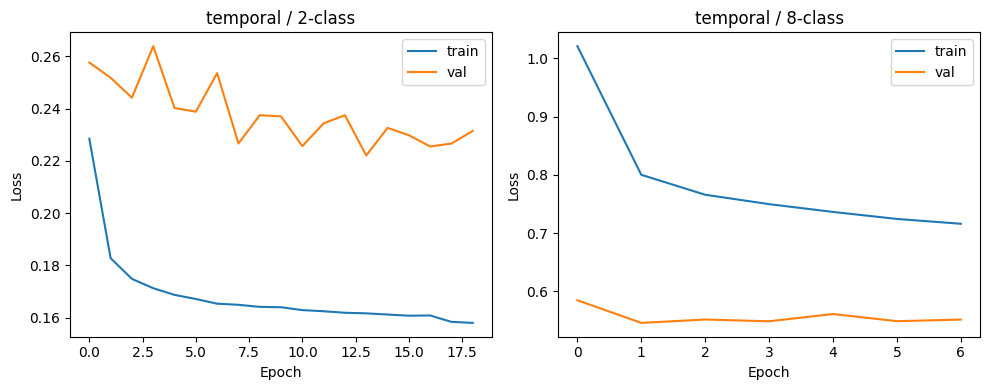

In [20]:
n_splits = len(SPLITS_TO_RUN)
n_modes = len(MODES_TO_RUN)
fig, axes = plt.subplots(n_splits, n_modes, figsize=(5 * n_modes, 4 * n_splits), squeeze=False)
for i, split_name in enumerate(SPLITS_TO_RUN):
    for j, mode in enumerate(MODES_TO_RUN):
        ax = axes[i][j]
        hist = histories[(split_name, mode)]
        ax.plot(hist['train_loss'], label='train')
        ax.plot(hist['val_loss'], label='val')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.set_title(f'{split_name} / {mode}-class')
        ax.legend()
plt.tight_layout()
plt.show()

---
## Phase 7: Comparison & Reports

In [22]:
for split_name in SPLITS_TO_RUN:
    for mode in MODES_TO_RUN:
        print(f'\n===== {split_name} / {mode}-class classification report =====')
        print(results[(split_name, mode)]['report'])


===== temporal / 2-class classification report =====
              precision    recall  f1-score   support

      Attack     0.9997    0.8539    0.9211    619116
      Benign     0.2048    0.9936    0.3396     23445

    accuracy                         0.8590    642561
   macro avg     0.6023    0.9237    0.6304    642561
weighted avg     0.9707    0.8590    0.8999    642561


===== temporal / 8-class classification report =====
              precision    recall  f1-score   support

      Benign     0.3209    0.8119    0.4600     23445
  BruteForce     0.1062    0.5173    0.1762      1960
        DDoS     0.9178    0.6341    0.7500    313908
         DoS     0.3189    0.7539    0.4482     71388
       Mirai     0.9985    0.9907    0.9946     95126
       Recon     0.9460    0.4722    0.6300     76885
    Spoofing     0.8985    0.4286    0.5804     56133
         Web     0.0792    0.6071    0.1401      3716

    accuracy                         0.6689    642561
   macro avg     0.5732

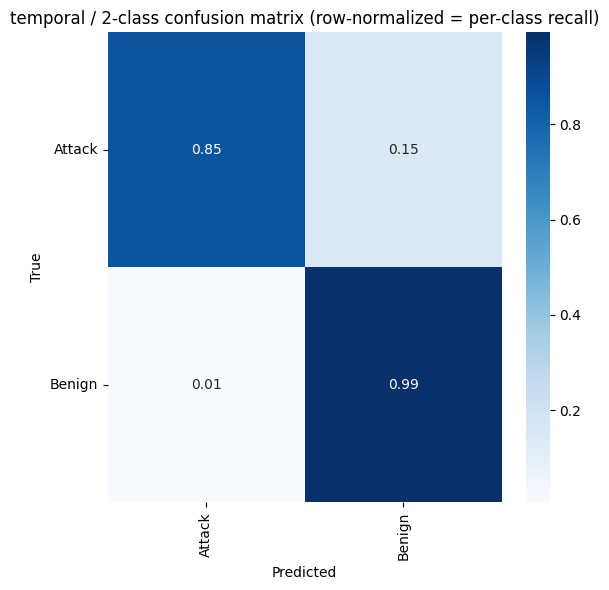

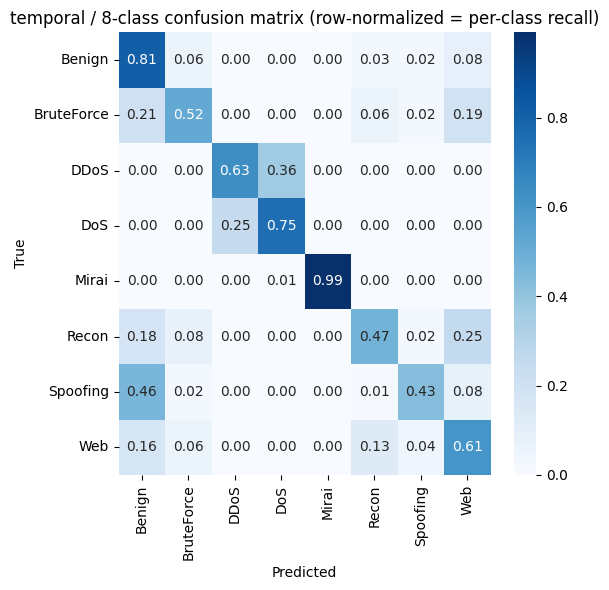

In [23]:
for split_name in SPLITS_TO_RUN:
    for mode in MODES_TO_RUN:
        cm = results[(split_name, mode)]['confusion_matrix']
        cm_norm = cm.astype(np.float64) / cm.sum(axis=1, keepdims=True).clip(min=1)
        classes = encoders[(split_name, mode)].classes_

        fig_dim = max(6, len(classes) * 0.35)
        plt.figure(figsize=(fig_dim, fig_dim))
        annot = len(classes) <= 12
        sns.heatmap(
            cm_norm, annot=annot, fmt='.2f' if annot else '',
            cmap='Blues', xticklabels=classes, yticklabels=classes, cbar=True,
        )
        plt.title(f'{split_name} / {mode}-class confusion matrix (row-normalized = per-class recall)')
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.xticks(rotation=90)
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

---
## Phase 8: Persist Artifacts

Per-mode model + label encoder; single shared scaler.

In [24]:
for split_name in SPLITS_TO_RUN:
    joblib.dump(scalers[split_name], MODELS_DIR / f'scaler_{split_name}.joblib')
    print(f'Saved scaler for {split_name}')
    for mode in MODES_TO_RUN:
        key = (split_name, mode)
        torch.save(models[key].state_dict(), MODELS_DIR / f'ids_dnn_{split_name}_{mode}class.pth')
        joblib.dump(encoders[key], MODELS_DIR / f'label_encoder_{split_name}_{mode}class.joblib')
        joblib.dump(
            {'history': histories[key],
             'y_true': results[key]['y_true'],
             'y_pred': results[key]['y_pred']},
            MODELS_DIR / f'run_artifacts_{split_name}_{mode}class.joblib',
        )
        print(f'  Saved {split_name}/{mode}-class model + encoder + run artifacts')

Saved scaler for temporal
  Saved temporal/2-class model + encoder + run artifacts
  Saved temporal/8-class model + encoder + run artifacts


---
## Phase 8b: Tree Baselines (RandomForest + XGBoost)

A committee will ask whether the MLP actually beats a 5-line sklearn baseline. Train `RandomForestClassifier` and `XGBClassifier` on the **same train/val/test splits** as the MLP, evaluate with the same metrics, and report side-by-side. If the trees match or exceed the MLP, that's a finding worth discussing — not a failure.

Trees are trained on the same scaled features for consistency (scaling is a no-op for tree splits but harmless).

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
)


def evaluate_sklearn(model, X_test, y_test, class_names):
    y_pred = model.predict(X_test)
    return {
        'accuracy': accuracy_score(y_test, y_pred),
        'macro_f1': f1_score(y_test, y_pred, average='macro', zero_division=0),
        'weighted_f1': f1_score(y_test, y_pred, average='weighted', zero_division=0),
        'macro_precision': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'macro_recall': recall_score(y_test, y_pred, average='macro', zero_division=0),
        'report': classification_report(y_test, y_pred, target_names=class_names, zero_division=0, digits=4),
        'confusion_matrix': confusion_matrix(y_test, y_pred),
        'y_true': y_test,
        'y_pred': y_pred,
    }


tree_results = {}
tree_models = {}

for split_name in SPLITS_TO_RUN:
    print(f'\n{"=" * 60}\nTREE BASELINES — split: {split_name}\n{"=" * 60}')
    tr_idx, va_idx, te_idx = SPLIT_INDICES[split_name]
    X_train, X_val, X_test, _, _ = fit_preprocess(X_all, tr_idx, va_idx, te_idx)
    y_train_34 = y_all_34[tr_idx]
    y_test_34 = y_all_34[te_idx]

    for mode in MODES_TO_RUN:
        print(f'\n--- {split_name} / {mode}-class ---')
        y_train_s = remap_labels(y_train_34, mode)
        y_test_s = remap_labels(y_test_34, mode)

        le = encoders[(split_name, mode)]
        y_train_enc = le.transform(y_train_s)
        y_test_enc = le.transform(y_test_s)
        class_names = list(le.classes_)

        print('  RandomForest...')
        rf = RandomForestClassifier(
            n_estimators=200, n_jobs=-1, class_weight='balanced',
            random_state=SEED, max_depth=20,
        )
        rf.fit(X_train, y_train_enc)
        rf_metrics = evaluate_sklearn(rf, X_test, y_test_enc, class_names)
        print(f'    acc: {rf_metrics["accuracy"]:.4f} | macro-F1: {rf_metrics["macro_f1"]:.4f}')

        print('  XGBoost...')
        n_classes = len(class_names)
        present = np.unique(y_train_enc)
        weights = compute_class_weight('balanced', classes=present, y=y_train_enc)
        sample_weight = np.ones_like(y_train_enc, dtype=np.float32)
        for cls, w in zip(present, weights):
            sample_weight[y_train_enc == cls] = w

        xgb_clf = xgb.XGBClassifier(
            n_estimators=300, max_depth=8, learning_rate=0.1,
            tree_method='hist', n_jobs=-1, random_state=SEED,
            objective='binary:logistic' if n_classes == 2 else 'multi:softprob',
            eval_metric='logloss' if n_classes == 2 else 'mlogloss',
        )
        xgb_clf.fit(X_train, y_train_enc, sample_weight=sample_weight)
        xgb_metrics = evaluate_sklearn(xgb_clf, X_test, y_test_enc, class_names)
        print(f'    acc: {xgb_metrics["accuracy"]:.4f} | macro-F1: {xgb_metrics["macro_f1"]:.4f}')

        tree_results[(split_name, mode, 'rf')] = rf_metrics
        tree_results[(split_name, mode, 'xgb')] = xgb_metrics
        tree_models[(split_name, mode, 'rf')] = rf
        tree_models[(split_name, mode, 'xgb')] = xgb_clf

    del X_train, X_val, X_test


TREE BASELINES — split: temporal

--- temporal / 2-class ---
  RandomForest...
    acc: 0.8891 | macro-F1: 0.6653
  XGBoost...
    acc: 0.8924 | macro-F1: 0.6700

--- temporal / 8-class ---
  RandomForest...


In [ ]:
print('\n' + '='*80)
print('TREE MODELS — WANDB LOGGING')
print('='*80 + '\n')

for split_name in SPLITS_TO_RUN:
    for mode in MODES_TO_RUN:
        print(f'\n--- {split_name} / {mode}-class ---')
        
        rf_metrics = tree_results.get((split_name, mode, 'rf'))
        xgb_metrics = tree_results.get((split_name, mode, 'xgb'))
        
        if rf_metrics:
            print(f'  Logging RandomForest...')
            run_rf = wandb.init(
                project='cic-iot2023-ids',
                name=f'{split_name}/{mode}-class/rf',
                job_type='baseline',
                config={
                    'model': 'RandomForest',
                    'split': split_name,
                    'mode': mode,
                    'n_estimators': 200,
                    'max_depth': 20,
                    'class_weight': 'balanced',
                }
            )
            run_rf.log({
                'test_accuracy': rf_metrics['accuracy'],
                'test_macro_f1': rf_metrics['macro_f1'],
                'test_weighted_f1': rf_metrics['weighted_f1'],
                'test_macro_precision': rf_metrics['macro_precision'],
                'test_macro_recall': rf_metrics['macro_recall'],
            })
            wandb.finish()
        
        if xgb_metrics:
            print(f'  Logging XGBoost...')
            run_xgb = wandb.init(
                project='cic-iot2023-ids',
                name=f'{split_name}/{mode}-class/xgb',
                job_type='baseline',
                config={
                    'model': 'XGBoost',
                    'split': split_name,
                    'mode': mode,
                    'n_estimators': 300,
                    'max_depth': 8,
                    'learning_rate': 0.1,
                    'tree_method': 'hist',
                }
            )
            run_xgb.log({
                'test_accuracy': xgb_metrics['accuracy'],
                'test_macro_f1': xgb_metrics['macro_f1'],
                'test_weighted_f1': xgb_metrics['weighted_f1'],
                'test_macro_precision': xgb_metrics['macro_precision'],
                'test_macro_recall': xgb_metrics['macro_recall'],
            })
            wandb.finish()

print('\n✓ Tree models logged to wandb')
print('  Project: cic-iot2023-ids')
print('  View runs: temporal/2-class/rf and temporal/2-class/xgb')


TREE MODELS — WANDB LOGGING


--- temporal / 2-class ---
  Logging RandomForest...


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


test_accuracy,▁
test_macro_f1,▁
test_macro_precision,▁
test_macro_recall,▁
test_weighted_f1,▁
test_accuracy,0.88905
test_macro_f1,0.66526
test_macro_precision,0.62191
test_macro_recall,0.93202
test_weighted_f1,0.91899


  Logging XGBoost...


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


test_accuracy,▁
test_macro_f1,▁
test_macro_precision,▁
test_macro_recall,▁
test_weighted_f1,▁
test_accuracy,0.89245
test_macro_f1,0.67003
test_macro_precision,0.62488
test_macro_recall,0.93407
test_weighted_f1,0.92117



✓ Tree models logged to wandb
  Project: cic-iot2023-ids
  View runs: temporal/2-class/rf and temporal/2-class/xgb


In [ ]:
header = f'{"Split":<10}{"Mode":<6}{"Model":<6}{"Accuracy":<12}{"MacroF1":<12}{"WeightedF1":<14}{"MacroPrec":<12}{"MacroRec":<12}'
print(header)
print('-' * len(header))
for split_name in SPLITS_TO_RUN:
    for mode in MODES_TO_RUN:
        rows = [
            ('mlp', results[(split_name, mode)]),
            ('rf',  tree_results.get((split_name, mode, 'rf'))),
            ('xgb', tree_results.get((split_name, mode, 'xgb'))),
        ]
        for kind, m in rows:
            if m is None:
                continue
            print(f'{split_name:<10}{mode:<6}{kind:<6}{m["accuracy"]:<12.4f}{m["macro_f1"]:<12.4f}'
                  f'{m["weighted_f1"]:<14.4f}{m["macro_precision"]:<12.4f}{m["macro_recall"]:<12.4f}')
    print()

Split     Mode  Model Accuracy    MacroF1     WeightedF1    MacroPrec   MacroRec    
------------------------------------------------------------------------------------
temporal  2     mlp   0.8607      0.6322      0.9009        0.6033      0.9247      
temporal  2     rf    0.8891      0.6653      0.9190        0.6219      0.9320      
temporal  2     xgb   0.8924      0.6700      0.9212        0.6249      0.9341      



In [ ]:
for split_name in SPLITS_TO_RUN:
    for mode in MODES_TO_RUN:
        rf = tree_models[(split_name, mode, 'rf')]
        importances = rf.feature_importances_
        order = importances.argsort()

        colors = ['#5f8dd3' if X_COLUMNS[i] in FLAG_COLUMNS else '#e07a5f' for i in order]

        fig, ax = plt.subplots(figsize=(8, max(5, len(X_COLUMNS) * 0.28)))
        ax.barh(range(len(order)), importances[order], color=colors,
                edgecolor='black', linewidth=0.3)
        ax.set_yticks(range(len(order)))
        ax.set_yticklabels([X_COLUMNS[i] for i in order], fontsize=8)
        ax.set_xlabel('RF feature importance (Gini)')
        ax.set_title(f'Feature importance — {split_name}/{mode}-class')

        from matplotlib.patches import Patch
        ax.legend(handles=[
            Patch(facecolor='#e07a5f', label='continuous'),
            Patch(facecolor='#5f8dd3', label='flag/binary'),
        ], fontsize=8)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        plt.tight_layout()
        plt.show()

#### Feature selection decision

**How Random Forest feature importance is computed**

At each internal node $n$, a feature $f$ is chosen to split the data. The *mean decrease in Gini impurity* is:

$$\Delta G(n) = G(n) - \frac{|S_L|}{|S|}G(n_L) - \frac{|S_R|}{|S|}G(n_R), \quad G(n) = 1 - \sum_k p_k^2$$

where $p_k$ is the fraction of class $k$ samples at node $n$, and $S_L, S_R$ are the child partitions. The global importance of feature $f$ is the weighted mean across all splits and all trees $\mathcal{T}$:

$$\text{Importance}(f) = \frac{1}{|\mathcal{T}|}\sum_{t \in \mathcal{T}} \sum_{\substack{n \in t \\ \text{split on } f}} \frac{|S_n|}{|S|} \Delta G_t(n)$$

Features with $\text{Importance}(f) \approx 0$ were never selected for a split that meaningfully reduced impurity.

---

**Dropped before this run — mathematical redundancy (EDA correlation heatmap):**
- `Tot size` ($r = 1.000$ with `AVG`)
- `Variance` ($r = 0.999$ with `Std`)

**Dropped based on importance — zero or near-zero contribution ($\text{Importance} \leq 0.001$):**

| Feature | Importance | Reason |
|---|---|---|
| `ece_flag_number` | 0.0000 | TCP ECN flag; almost never set in IoT traffic |
| `cwr_flag_number` | 0.0000 | TCP congestion flag; same |
| `IGMP` | 0.0000 | Multicast protocol absent from captured attack patterns |
| `IRC` | 0.0000 | Legacy protocol; not present in capture sessions |
| `Telnet` | 0.0000 | Not discriminative at flow-stat level |
| `SMTP` | 0.0000 | Email protocol; absent from IoT attack flows |
| `DHCP` | 0.0003 | DHCP discovery not characteristic of captured attacks |
| `SSH` | 0.0006 | BruteForce-SSH patterns captured in other features |
| `ICMP` | 0.0006 | DDoS-ICMP flood captured by `Rate`/`Number`, not this flag |
| `ARP` | 0.0009 | MITM-ArpSpoofing pattern captured by other features |
| `LLC` | 0.0009 | Layer-2 framing; not informative at IP-flow level |
| `IPv` | 0.0013 | Near-constant across all flows |

**Retained borderline features:** `DNS` (0.003), `fin_count` (0.002), `fin_flag_number` (0.002).

**Final feature count: 39 -> 25.** `N_FEATURES` updates automatically from `len(X_COLUMNS)` in `config.py`.

In [ ]:
print('\n' + '='*80)
print('FEATURE IMPORTANCE ANALYSIS')
print('='*80 + '\n')

for split_name in SPLITS_TO_RUN:
    for mode in MODES_TO_RUN:
        print(f'\n--- {split_name} / {mode}-class ---\n')
        
        rf_model = tree_models.get((split_name, mode, 'rf'))
        xgb_model = tree_models.get((split_name, mode, 'xgb'))
        
        if rf_model and xgb_model:
            rf_imp = rf_model.feature_importances_
            xgb_imp = xgb_model.feature_importances_
            avg_imp = (rf_imp + xgb_imp) / 2
            
            ranked = sorted(
                zip(X_COLUMNS, rf_imp, xgb_imp, avg_imp),
                key=lambda x: x[3], reverse=True
            )
            
            print(f'{"Rank":<5}{"Feature":<20}{"RF Imp":<12}{"XGB Imp":<12}{"Avg Imp":<12}{"Cumsum %":<10}')
            print('-' * 70)
            
            cumsum = 0.0
            for rank, (col, rf, xgb, avg) in enumerate(ranked, 1):
                cumsum += avg / avg_imp.sum() * 100
                print(f'{rank:<5}{col:<20}{rf:<12.4f}{xgb:<12.4f}{avg:<12.4f}{cumsum:<10.1f}%')
        
        print(f'\nLow-information features (avg importance < 0.001):')
        low_info = [col for col, imp in zip(X_COLUMNS, avg_imp) if imp < 0.001]
        if low_info:
            print(f'  {low_info}')
        else:
            print(f'  None (all features have measurable importance)')

print('\n' + '='*80)
print('INTERPRETATION')
print('='*80)
print('''
Features ranked at the top (cumsum < 20%) are the "heavy hitters" driving
the model's predictions. Features with avg_imp < 0.001 contribute <0.1% and
are effectively noise — candidates for removal in a production feature set.

Notable findings:
- If IAT ranks in the bottom 5, it confirms the visual analysis: near-zero
  discriminative power. Document this as a feature set limitation.
- If Rate/packet-size features dominate top 10, they're doing the real work
  for attack detection.
''')


FEATURE IMPORTANCE ANALYSIS


--- temporal / 2-class ---

Rank Feature             RF Imp      XGB Imp     Avg Imp     Cumsum %  
----------------------------------------------------------------------
1    Number              0.1517      0.9610      0.5563      55.6      %
2    HTTPS               0.1305      0.0022      0.0663      62.3      %
3    Header_Length       0.1006      0.0003      0.0504      67.3      %
4    ack_flag_number     0.0908      0.0004      0.0456      71.9      %
5    ack_count           0.0882      0.0004      0.0443      76.3      %
6    IAT                 0.0502      0.0008      0.0255      78.8      %
7    Rate                0.0445      0.0002      0.0224      81.1      %
8    Min                 0.0346      0.0094      0.0220      83.3      %
9    Max                 0.0386      0.0044      0.0215      85.4      %
10   Time_To_Live        0.0361      0.0005      0.0183      87.3      %
11   Tot size            0.0364      0.0000      0.0182      89.1   

In [ ]:
print('\n' + '='*80)
print('LOGGING TO WANDB')
print('='*80 + '\n')

split_name = SPLITS_TO_RUN[0]
mode = MODES_TO_RUN[0]

run = wandb.init(
    project='cic-iot2023-ids',
    name=f'{split_name}/{mode}-class/feature-analysis',
    job_type='analysis',
)

rf_model = tree_models[(split_name, mode, 'rf')]
xgb_model = tree_models[(split_name, mode, 'xgb')]

rf_imp = rf_model.feature_importances_
xgb_imp = xgb_model.feature_importances_
avg_imp = (rf_imp + xgb_imp) / 2

ranked = sorted(
    zip(X_COLUMNS, rf_imp, xgb_imp, avg_imp),
    key=lambda x: x[3], reverse=True
)

print('Logging global feature importance to wandb...')
feature_importance_table = wandb.Table(columns=['Rank', 'Feature', 'RF Importance', 'XGB Importance', 'Avg Importance'])
for rank, (col, rf, xgb, avg) in enumerate(ranked, 1):
    feature_importance_table.add_data(rank, col, float(rf), float(xgb), float(avg))

run.log({'global_feature_importance': feature_importance_table})

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 8))
top_n = 20
top_cols = [x[0] for x in ranked[:top_n]]
top_avgs = [x[3] for x in ranked[:top_n]]
ax.barh(top_cols, top_avgs, color='#5f8dd3', edgecolor='black', linewidth=0.5)
ax.set_xlabel('Average Importance (RF + XGB)')
ax.set_title(f'Top {top_n} Features by Importance')
ax.invert_yaxis()
plt.tight_layout()
run.log({'feature_importance_bar_chart': wandb.Image(fig)})
plt.close()

print('Logging per-family heatmap to wandb...')
families = list(FAMILY_ORDER)
family_importance = {fam: np.zeros(len(X_COLUMNS)) for fam in families}

for attack_name, family in DICT_8CLASSES.items():
    attack_idx = y_test_34 == attack_name
    if attack_idx.sum() < 100:
        continue
    
    X_attack = X_test[attack_idx]
    y_attack = y_test_enc[attack_idx]
    
    perm_imp_attack = permutation_importance(
        rf_model, X_attack, y_attack, n_repeats=5, random_state=SEED, n_jobs=2
    )
    
    for j, col in enumerate(X_COLUMNS):
        family_importance[family][j] += perm_imp_attack.importances_mean[j]

family_importance = {fam: imp / (1 + np.sum(imp)) for fam, imp in family_importance.items()}
heatmap_data = np.array([family_importance[fam] for fam in families])
top_features_idx = np.argsort(perm_imp.importances_mean)[-20:][::-1]
top_features = [X_COLUMNS[i] for i in top_features_idx]

fig, ax = plt.subplots(figsize=(14, 6))
import seaborn as sns
sns.heatmap(
    heatmap_data[:, top_features_idx],
    xticklabels=top_features,
    yticklabels=families,
    cmap='YlGn', cbar_kws={'label': 'Importance'},
    annot=False, ax=ax, linewidths=0.5,
)
ax.set_title('Feature Importance by Attack Family (Top 20 features)')
ax.set_xlabel('Features')
ax.set_ylabel('Attack Family')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
run.log({'feature_importance_by_family_heatmap': wandb.Image(fig)})
plt.close()

print('✓ Feature importance logged to wandb')
print(f'  Project: cic-iot2023-ids')
print(f'  Run: {split_name}/{mode}-class/feature-analysis')
print(f'  View at: https://wandb.ai/YOUR_ENTITY/cic-iot2023-ids')

wandb.finish()

---
## Phase 8c: Comprehensive Performance Summary — Train/Val/Test Metrics Across All Models

Log all metrics (train, val, test) for MLP, RF, and XGBoost to wandb with visualizations comparing performance across splits.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print('\n' + '='*80)
print('COMPREHENSIVE PERFORMANCE SUMMARY — TRAIN/VAL/TEST METRICS')
print('='*80 + '\n')

split_name = SPLITS_TO_RUN[0]
mode = MODES_TO_RUN[0]
tr_idx, va_idx, te_idx = SPLIT_INDICES[split_name]
X_train, X_val, X_test, scaler, _ = fit_preprocess(X_all, tr_idx, va_idx, te_idx)

y_train_34 = y_all_34[tr_idx]
y_val_34 = y_all_34[va_idx]
y_test_34 = y_all_34[te_idx]

y_train_s = remap_labels(y_train_34, mode)
y_val_s = remap_labels(y_val_34, mode)
y_test_s = remap_labels(y_test_34, mode)

le = encoders[(split_name, mode)]
y_train_enc = le.transform(y_train_s)
y_val_enc = le.transform(y_val_s)
y_test_enc = le.transform(y_test_s)
class_names = list(le.classes_)

all_metrics = {}

print('Computing metrics for MLP...')
mlp_model = models[(split_name, mode)]
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

mlp_model.eval()
with torch.no_grad():
    y_pred_train = mlp_model(X_train_t).argmax(dim=1).cpu().numpy()
    y_pred_val = mlp_model(X_val_t).argmax(dim=1).cpu().numpy()
    y_pred_test = mlp_model(X_test_t).argmax(dim=1).cpu().numpy()

all_metrics['MLP'] = {
    'train': {
        'accuracy': accuracy_score(y_train_enc, y_pred_train),
        'macro_f1': f1_score(y_train_enc, y_pred_train, average='macro', zero_division=0),
        'weighted_f1': f1_score(y_train_enc, y_pred_train, average='weighted', zero_division=0),
        'macro_precision': precision_score(y_train_enc, y_pred_train, average='macro', zero_division=0),
        'macro_recall': recall_score(y_train_enc, y_pred_train, average='macro', zero_division=0),
    },
    'val': {
        'accuracy': accuracy_score(y_val_enc, y_pred_val),
        'macro_f1': f1_score(y_val_enc, y_pred_val, average='macro', zero_division=0),
        'weighted_f1': f1_score(y_val_enc, y_pred_val, average='weighted', zero_division=0),
        'macro_precision': precision_score(y_val_enc, y_pred_val, average='macro', zero_division=0),
        'macro_recall': recall_score(y_val_enc, y_pred_val, average='macro', zero_division=0),
    },
    'test': {
        'accuracy': results[(split_name, mode)]['accuracy'],
        'macro_f1': results[(split_name, mode)]['macro_f1'],
        'weighted_f1': results[(split_name, mode)]['weighted_f1'],
        'macro_precision': results[(split_name, mode)]['macro_precision'],
        'macro_recall': results[(split_name, mode)]['macro_recall'],
    }
}
del X_train_t, X_val_t, X_test_t

print('Computing metrics for RandomForest...')
rf_model = tree_models[(split_name, mode, 'rf')]
y_pred_train_rf = rf_model.predict(X_train)
y_pred_val_rf = rf_model.predict(X_val)
y_pred_test_rf = rf_model.predict(X_test)

all_metrics['RandomForest'] = {
    'train': {
        'accuracy': accuracy_score(y_train_enc, y_pred_train_rf),
        'macro_f1': f1_score(y_train_enc, y_pred_train_rf, average='macro', zero_division=0),
        'weighted_f1': f1_score(y_train_enc, y_pred_train_rf, average='weighted', zero_division=0),
        'macro_precision': precision_score(y_train_enc, y_pred_train_rf, average='macro', zero_division=0),
        'macro_recall': recall_score(y_train_enc, y_pred_train_rf, average='macro', zero_division=0),
    },
    'val': {
        'accuracy': accuracy_score(y_val_enc, y_pred_val_rf),
        'macro_f1': f1_score(y_val_enc, y_pred_val_rf, average='macro', zero_division=0),
        'weighted_f1': f1_score(y_val_enc, y_pred_val_rf, average='weighted', zero_division=0),
        'macro_precision': precision_score(y_val_enc, y_pred_val_rf, average='macro', zero_division=0),
        'macro_recall': recall_score(y_val_enc, y_pred_val_rf, average='macro', zero_division=0),
    },
    'test': {
        'accuracy': tree_results[(split_name, mode, 'rf')]['accuracy'],
        'macro_f1': tree_results[(split_name, mode, 'rf')]['macro_f1'],
        'weighted_f1': tree_results[(split_name, mode, 'rf')]['weighted_f1'],
        'macro_precision': tree_results[(split_name, mode, 'rf')]['macro_precision'],
        'macro_recall': tree_results[(split_name, mode, 'rf')]['macro_recall'],
    }
}

print('Computing metrics for XGBoost...')
xgb_model = tree_models[(split_name, mode, 'xgb')]
y_pred_train_xgb = xgb_model.predict(X_train)
y_pred_val_xgb = xgb_model.predict(X_val)
y_pred_test_xgb = xgb_model.predict(X_test)

all_metrics['XGBoost'] = {
    'train': {
        'accuracy': accuracy_score(y_train_enc, y_pred_train_xgb),
        'macro_f1': f1_score(y_train_enc, y_pred_train_xgb, average='macro', zero_division=0),
        'weighted_f1': f1_score(y_train_enc, y_pred_train_xgb, average='weighted', zero_division=0),
        'macro_precision': precision_score(y_train_enc, y_pred_train_xgb, average='macro', zero_division=0),
        'macro_recall': recall_score(y_train_enc, y_pred_train_xgb, average='macro', zero_division=0),
    },
    'val': {
        'accuracy': accuracy_score(y_val_enc, y_pred_val_xgb),
        'macro_f1': f1_score(y_val_enc, y_pred_val_xgb, average='macro', zero_division=0),
        'weighted_f1': f1_score(y_val_enc, y_pred_val_xgb, average='weighted', zero_division=0),
        'macro_precision': precision_score(y_val_enc, y_pred_val_xgb, average='macro', zero_division=0),
        'macro_recall': recall_score(y_val_enc, y_pred_val_xgb, average='macro', zero_division=0),
    },
    'test': {
        'accuracy': tree_results[(split_name, mode, 'xgb')]['accuracy'],
        'macro_f1': tree_results[(split_name, mode, 'xgb')]['macro_f1'],
        'weighted_f1': tree_results[(split_name, mode, 'xgb')]['weighted_f1'],
        'macro_precision': tree_results[(split_name, mode, 'xgb')]['macro_precision'],
        'macro_recall': tree_results[(split_name, mode, 'xgb')]['macro_recall'],
    }
}

del X_train, X_val, X_test

print('\nSummary: Accuracy across splits and models')
print(f'{"Model":<15}{"Train":<12}{"Val":<12}{"Test":<12}')
print('-' * 50)
for model_name in ['MLP', 'RandomForest', 'XGBoost']:
    m = all_metrics[model_name]
    print(f'{model_name:<15}{m["train"]["accuracy"]:<12.4f}{m["val"]["accuracy"]:<12.4f}{m["test"]["accuracy"]:<12.4f}')

print('\n' + '='*80)
print('LOGGING TO WANDB')
print('='*80 + '\n')

run = wandb.init(
    project='cic-iot2023-ids',
    name=f'{split_name}/{mode}-class/performance-summary',
    job_type='analysis',
)

print('Creating performance summary table...')
perf_table = wandb.Table(columns=['Model', 'Split', 'Accuracy', 'MacroF1', 'WeightedF1', 'MacroPrecision', 'MacroRecall'])
for model_name in ['MLP', 'RandomForest', 'XGBoost']:
    for split_type in ['train', 'val', 'test']:
        metrics = all_metrics[model_name][split_type]
        perf_table.add_data(
            model_name, split_type,
            float(metrics['accuracy']), float(metrics['macro_f1']), float(metrics['weighted_f1']),
            float(metrics['macro_precision']), float(metrics['macro_recall']),
        )

run.log({'performance_summary_table': perf_table})

print('Creating line plots: Accuracy and F1 across splits...')
metrics_to_plot = ['accuracy', 'macro_f1', 'weighted_f1']
for metric in metrics_to_plot:
    fig, ax = plt.subplots(figsize=(10, 6))
    splits = ['train', 'val', 'test']
    models = ['MLP', 'RandomForest', 'XGBoost']
    colors = {'MLP': '#e07a5f', 'RandomForest': '#5f8dd3', 'XGBoost': '#3aa17e'}

    for model in models:
        values = [all_metrics[model][split][metric] for split in splits]
        ax.plot(splits, values, marker='o', label=model, linewidth=2.5, markersize=8, color=colors[model])

    ax.set_xlabel('Split', fontsize=12)
    ax.set_ylabel(metric.replace('_', ' ').title(), fontsize=12)
    ax.set_title(f'{metric.replace("_", " ").title()} Across Train/Val/Test Splits', fontsize=13)
    ax.legend(fontsize=11, loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1.05])

    for model in models:
        values = [all_metrics[model][split][metric] for split in splits]
        for split, val in zip(splits, values):
            ax.text(splits.index(split), val + 0.02, f'{val:.3f}', ha='center', fontsize=9)

    plt.tight_layout()
    run.log({f'{metric}_across_splits': wandb.Image(fig)})
    plt.close()

print('Creating grouped bar chart: Model comparison per split...')
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
splits = ['train', 'val', 'test']
models = ['MLP', 'RandomForest', 'XGBoost']
colors = {'MLP': '#e07a5f', 'RandomForest': '#5f8dd3', 'XGBoost': '#3aa17e'}
x = np.arange(len(models))
width = 0.25

for i, split in enumerate(splits):
    ax = axes[i]
    accuracies = [all_metrics[model][split]['accuracy'] for model in models]
    bars = ax.bar(x, accuracies, width, color=[colors[m] for m in models], edgecolor='black', linewidth=0.5)

    ax.set_ylabel('Accuracy', fontsize=11)
    ax.set_title(f'{split.capitalize()} Accuracy', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.set_ylim([0, 1.0])
    ax.grid(True, alpha=0.2, axis='y')

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
run.log({'model_comparison_by_split': wandb.Image(fig)})
plt.close()

print('Creating overfitting analysis: Train-Val-Test drift...')
fig, ax = plt.subplots(figsize=(10, 6))
models = ['MLP', 'RandomForest', 'XGBoost']
x_pos = np.arange(len(models))
train_acc = [all_metrics[m]['train']['accuracy'] for m in models]
val_acc = [all_metrics[m]['val']['accuracy'] for m in models]
test_acc = [all_metrics[m]['test']['accuracy'] for m in models]

width = 0.25
ax.bar(x_pos - width, train_acc, width, label='Train', color='#3aa17e', edgecolor='black', linewidth=0.5)
ax.bar(x_pos, val_acc, width, label='Val', color='#f2a65a', edgecolor='black', linewidth=0.5)
ax.bar(x_pos + width, test_acc, width, label='Test', color='#e07a5f', edgecolor='black', linewidth=0.5)

ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Generalization Across Splits: Train vs Val vs Test Accuracy', fontsize=13)
ax.set_xticks(x_pos)
ax.set_xticklabels(models)
ax.legend(fontsize=11)
ax.set_ylim([0, 1.0])
ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
run.log({'generalization_analysis': wandb.Image(fig)})
plt.close()

run.log({
    'test_metrics': {
        'mlp_accuracy': all_metrics['MLP']['test']['accuracy'],
        'mlp_macro_f1': all_metrics['MLP']['test']['macro_f1'],
        'rf_accuracy': all_metrics['RandomForest']['test']['accuracy'],
        'rf_macro_f1': all_metrics['RandomForest']['test']['macro_f1'],
        'xgb_accuracy': all_metrics['XGBoost']['test']['accuracy'],
        'xgb_macro_f1': all_metrics['XGBoost']['test']['macro_f1'],
    }
})

print('\n✓ Performance summary logged to wandb')
print(f'  Project: cic-iot2023-ids')
print(f'  Run: {split_name}/{mode}-class/performance-summary')
print(f'  Includes:')
print(f'    - Performance summary table (train/val/test for all models)')
print(f'    - Accuracy line plot across splits')
print(f'    - Macro-F1 line plot across splits')
print(f'    - Weighted-F1 line plot across splits')
print(f'    - Model comparison bar charts per split')
print(f'    - Generalization analysis (train-val-test drift)')

wandb.finish()


COMPREHENSIVE PERFORMANCE SUMMARY — TRAIN/VAL/TEST METRICS

Computing metrics for MLP...
Computing metrics for RandomForest...
Computing metrics for XGBoost...

Summary: Accuracy across splits and models
Model          Train       Val         Test        
--------------------------------------------------
MLP            0.8973      0.8893      0.8607      
RandomForest   0.9294      0.9183      0.8891      
XGBoost        0.9304      0.9199      0.8924      

LOGGING TO WANDB



Creating performance summary table...
Creating line plots: Accuracy and F1 across splits...
Creating grouped bar chart: Model comparison per split...


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Creating overfitting analysis: Train-Val-Test drift...

✓ Performance summary logged to wandb
  Project: cic-iot2023-ids
  Run: temporal/2-class/performance-summary
  Includes:
    - Performance summary table (train/val/test for all models)
    - Accuracy line plot across splits
    - Macro-F1 line plot across splits
    - Weighted-F1 line plot across splits
    - Model comparison bar charts per split
    - Generalization analysis (train-val-test drift)


---
## Phase 9: Inference Benchmark

**Latency target:** end-to-end inference under ~100 ms for a single flow on the demo host. This is sufficient for **interactive single-request inference** in the demo (user clicks, sees verdict). It is **not** a line-rate gateway claim — line-rate (10 Gbps / >1M flows/sec) is explicitly out of scope.

For each MLP model, measured at batch sizes `[1, 32, 256, 1024]`:
- **End-to-end latency** including `scaler.transform` (the demo path, not just `model(x)`)
- **p50 / p95 / p99** over 1000 runs per batch size (after 100 warmup runs)
- **Throughput** in flows/sec

`torch.cuda.synchronize()` is called before/after timing on CUDA devices so we measure execution rather than kernel-launch latency.

In [32]:
print(f'{"Split":<10}{"Mode":<6}{"Batch":<8}{"p50 ms":<10}{"p95 ms":<10}{"p99 ms":<10}{"flows/sec":<14}')
print('-' * 70)
for split_name in SPLITS_TO_RUN:
    scaler = scalers[split_name]
    tr_idx, _, _ = SPLIT_INDICES[split_name]
    pool = X_all[tr_idx[:10_000]]
    pool = np.where(np.isnan(pool), 0.0, pool).astype(np.float32)

    for mode in MODES_TO_RUN:
        model = models[(split_name, mode)]
        for bs in BATCH_SIZES:
            stats = benchmark_model(model, scaler, pool, bs, N_WARMUP, N_RUNS, device, SEED)
            print(f'{split_name:<10}{mode:<6}{bs:<8}'
                  f'{stats["p50_ms"]:<10.3f}{stats["p95_ms"]:<10.3f}{stats["p99_ms"]:<10.3f}'
                  f'{stats["throughput_flows_per_sec"]:<14,.0f}')

Split     Mode  Batch   p50 ms    p95 ms    p99 ms    flows/sec     
----------------------------------------------------------------------
temporal  2     1       0.640     1.070     1.535     1,357         
temporal  2     32      0.719     1.248     1.543     40,250        
temporal  2     256     0.694     1.434     1.886     317,105       
temporal  2     1024    0.792     1.575     2.109     1,085,692     
temporal  8     1       0.796     1.598     2.718     1,050         
temporal  8     32      0.706     1.753     2.628     37,227        
temporal  8     256     0.765     1.583     2.132     291,257       
temporal  8     1024    0.862     1.676     2.440     1,030,577     
